<a href="https://colab.research.google.com/github/aimlnielitropar/BTech-DL/blob/main/practical3_optimizer_showdown.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/drive/1EdutW4SPAz7I3CJ79bPtHvbRjBy_C1kt?usp=sharing">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Practical 3: The Optimizer Showdown & Hyperparameter Tuning
## Deep Learning Lab | BTech Semester 4

### Objective
Analyze the impact of different optimization algorithms on convergence speed.

### References
- Ruder, S. (2016) — An Overview of Gradient Descent Optimization Algorithms (https://arxiv.org/abs/1609.04747)
- Goodfellow et al. — Deep Learning Ch. 8
- Keras Optimizers: https://keras.io/api/optimizers/
- Fashion MNIST: https://github.com/zalandoresearch/fashion-mnist

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


## Step 2: Load Fashion MNIST
Fashion MNIST has 70,000 grayscale images (28x28 pixels) of 10 clothing categories — a harder alternative to handwritten digits.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training: (60000, 28, 28), Test: (10000, 28, 28)


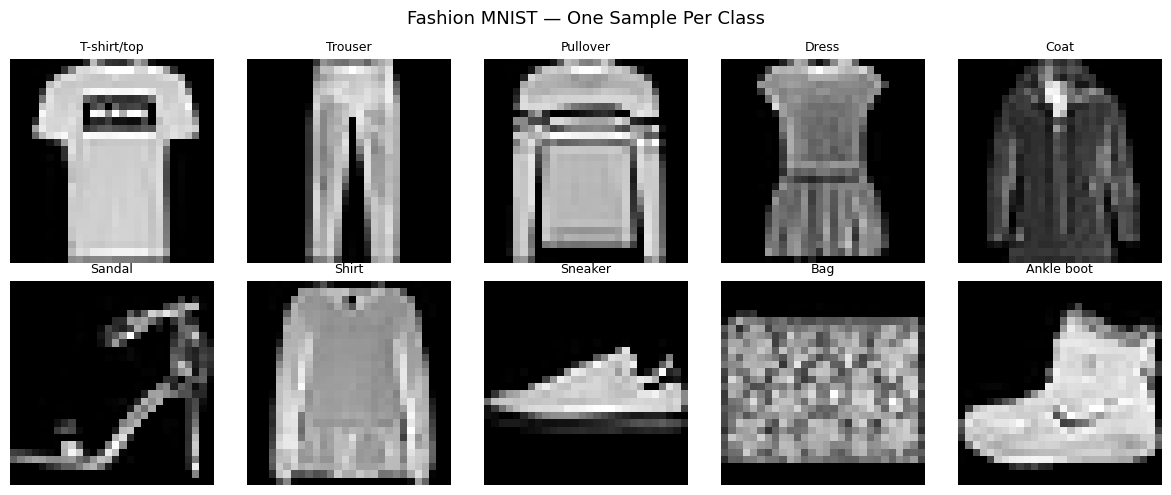

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Training: {X_train.shape}, Test: {X_test.shape}')

# showing one sample image for each clothing category
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(class_names[i], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion MNIST — One Sample Per Class', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: Preprocess Data
- Normalize pixels from [0,255] to [0,1] — smaller values help gradient descent converge faster
- Flatten 28x28 images into 784-length vectors for Dense layers

In [ ]:
X_train_flat = X_train.reshape(-1, 784) / 255.0
X_test_flat  = X_test.reshape(-1, 784)  / 255.0

# Subset for faster training on CPU (increase if you have GPU)
SUBSET = 15000  # using only 15000 samples so training doesn't take too long on CPU
X_sub = X_train_flat[:SUBSET]
y_sub = y_train[:SUBSET]
print(f'Subset shape: {X_sub.shape}, pixel range: [{X_sub.min():.1f}, {X_sub.max():.1f}]')

Subset shape: (15000, 784), pixel range: [0.0, 1.0]


## Step 4: Optimizer Theory

**SGD:** W = W - lr * gradient  — simple but slow

**SGD + Momentum:** velocity = beta*v + lr*gradient; W = W - velocity — adds inertia

**Nesterov:** computes gradient at future predicted position (look-ahead) — smarter momentum

**Adam:** adapts learning rate per parameter using estimates of first and second moments of gradients

In [ ]:
def build_network():
    """same network architecture used for all optimizers
    this way the only thing different between experiments is the optimizer itself"""
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,), name='hidden1'),
        layers.Dense(64,  activation='relu', name='hidden2'),
        layers.Dense(10,  activation='softmax', name='output')  # output layer with 10 neurons for 10 clothing categories
    ])
    return model

# defining three different optimizers we want to compare
optimizer_configs = [
    {'name': '1. SGD (lr=0.01)',
     'optimizer': optimizers.SGD(learning_rate=0.01),
     'color': 'red', 'linestyle': '-'},
    {'name': '2. SGD + Momentum + Nesterov',
     'optimizer': optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
     'color': 'blue', 'linestyle': '--'},
    {'name': '3. Adam (lr=0.001)',
     'optimizer': optimizers.Adam(learning_rate=0.001),
     'color': 'green', 'linestyle': '-.'},
]

print('Optimizer configurations:')
for c in optimizer_configs:
    print(f'  {c["name"]}')

Optimizer configurations:
  1. SGD (lr=0.01)
  2. SGD + Momentum + Nesterov
  3. Adam (lr=0.001)


## Step 5: Train All Three Configurations
Each model starts with the SAME random weights (same seed) for a fair comparison.

In [ ]:
EPOCHS = 30
BATCH_SIZE = 64
results = {}

for cfg in optimizer_configs:
    print(f'\nTraining: {cfg["name"]}')
    tf.random.set_seed(42)  # resetting to same seed so all models start with identical weights — fair comparison
    model = build_network()
    model.compile(
        optimizer=cfg['optimizer'],
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(X_sub, y_sub, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.15, verbose=0)
    results[cfg['name']] = {'history': history, 'color': cfg['color'],
                             'linestyle': cfg['linestyle'], 'model': model}
    print(f'  Final Val Acc: {history.history["val_accuracy"][-1]*100:.2f}%')

print('\nAll configurations trained!')


Training: 1. SGD (lr=0.01)
  Final Val Acc: 84.09%

Training: 2. SGD + Momentum + Nesterov
  Final Val Acc: 84.67%

Training: 3. Adam (lr=0.001)
  Final Val Acc: 86.58%

All configurations trained!


## Step 6: Compare Convergence — Loss vs. Epochs (Main Plot)

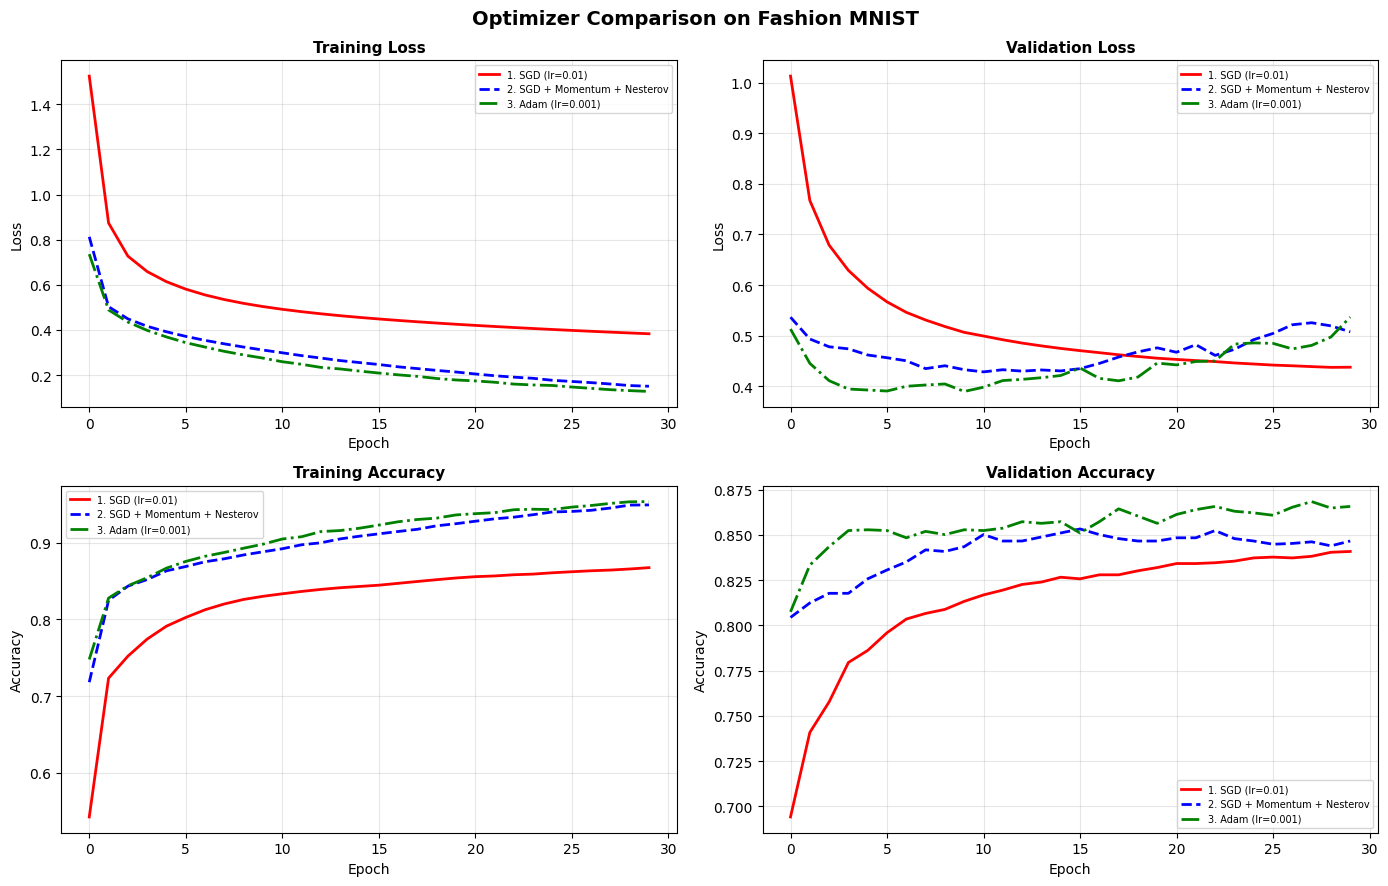

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_configs = [
    ('loss',         'Training Loss',      axes[0,0]),
    ('val_loss',     'Validation Loss',    axes[0,1]),
    ('accuracy',     'Training Accuracy',  axes[1,0]),
    ('val_accuracy', 'Validation Accuracy',axes[1,1]),
]

for metric, title, ax in plot_configs:
    for name, res in results.items():
        ax.plot(res['history'].history[metric],
                color=res['color'], linestyle=res['linestyle'],
                linewidth=2, label=name)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.replace('val_', '').replace('_', ' ').title())
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison on Fashion MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Summary Comparison Table

In [ ]:
rows = []
for name, res in results.items():
    h = res['history'].history
    test_loss, test_acc = res['model'].evaluate(X_test_flat, y_test, verbose=0)
    rows.append({
        'Optimizer': name,
        'Train Loss': f"{h['loss'][-1]:.4f}",
        'Val Loss': f"{h['val_loss'][-1]:.4f}",
        'Train Acc': f"{h['accuracy'][-1]*100:.1f}%",
        'Val Acc': f"{h['val_accuracy'][-1]*100:.1f}%",
        'Test Acc': f"{test_acc*100:.1f}%"
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\nObservations:')
print('  Adam usually wins — fastest convergence and best accuracy.')
print('  Momentum/Nesterov beats plain SGD by a good margin.')
print('  Plain SGD is slowest but can still generalize well if you tune learning rate carefully.')

                   Optimizer Train Loss Val Loss Train Acc Val Acc Test Acc
            1. SGD (lr=0.01)     0.3829   0.4378     86.8%   84.1%    83.1%
2. SGD + Momentum + Nesterov     0.1502   0.5077     95.0%   84.7%    84.1%
          3. Adam (lr=0.001)     0.1271   0.5368     95.4%   86.6%    85.3%

Observations:
  Adam usually converges fastest and achieves the best accuracy.
  Momentum/Nesterov clearly outperforms vanilla SGD.
  Vanilla SGD converges slowest but can generalize with careful tuning.


## Step 8: Loss Landscape Intuition

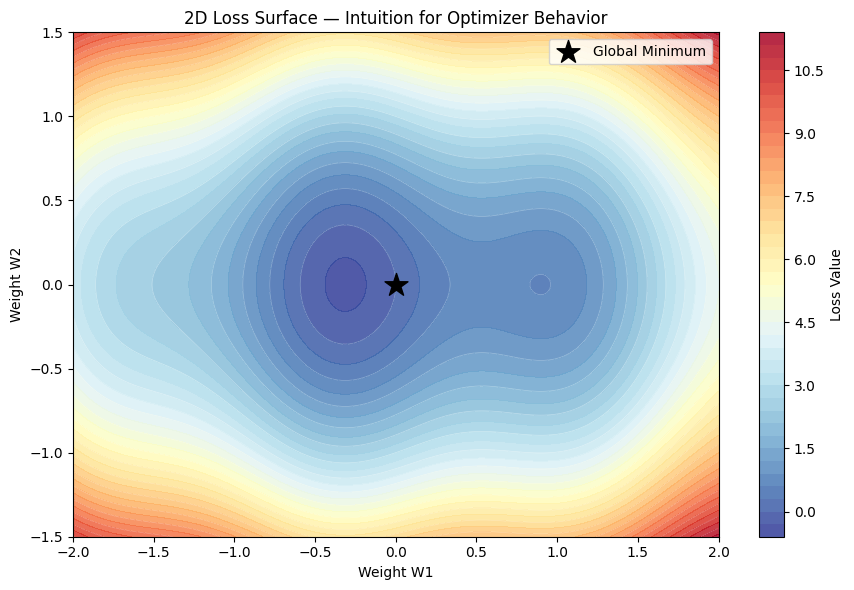

SGD oscillates in curved valleys. Momentum dampens oscillations. Adam adapts step size per dimension.


In [ ]:
# drawing a simplified 2D loss surface to give intuition about how optimizers behave
x = np.linspace(-2, 2, 200)
y = np.linspace(-1.5, 1.5, 200)
X_g, Y_g = np.meshgrid(x, y)
Z_g = X_g**2 + 3*Y_g**2 + 0.5*np.sin(4*X_g)

plt.figure(figsize=(9, 6))
plt.contourf(X_g, Y_g, Z_g, levels=40, cmap='RdYlBu_r', alpha=0.85)
plt.colorbar(label='Loss Value')
plt.contour(X_g, Y_g, Z_g, levels=20, colors='white', linewidths=0.5, alpha=0.4)
plt.scatter([0], [0], s=300, color='black', zorder=5, marker='*', label='Global Minimum')  # marking the lowest point
plt.title('2D Loss Surface — Intuition for Optimizer Behavior')
plt.xlabel('Weight W1'); plt.ylabel('Weight W2')
plt.legend()
plt.tight_layout()
plt.show()
print('SGD zigzags in curved valleys. Momentum smooths this out. Adam automatically adjusts step size for each weight.')

---
## Summary Table

| Optimizer | Key Idea | Strength | Weakness |
|-----------|---------|----------|----------|
| SGD | Fixed LR gradient steps | Simple, generalizes well | Slow, oscillates |
| SGD+Momentum | Accumulated velocity | Faster, smoother | Needs LR/momentum tuning |
| Nesterov | Look-ahead gradient | More accurate momentum | Slightly complex |
| Adam | Adaptive per-param LR | Fast, robust, minimal tuning | May overfit on small data |

---
## Viva / Self-Check Questions

1. What is the difference between Batch GD, SGD, and Mini-Batch GD? What are the trade-offs?
2. How does Momentum improve upon vanilla SGD? Use the ball-rolling-downhill analogy.
3. What does Nesterov add to Momentum-based SGD? Why is it called a look-ahead method?
4. Adam combines Momentum and RMSProp. Explain what each contributes.
5. What happens if the learning rate is too high? Too low? Sketch loss curves for both.
6. From the plots: which optimizer reached the lowest validation loss fastest? Why?
7. What is sparse_categorical_crossentropy? When is it used instead of categorical_crossentropy?
8. Why was the same random seed used before training each model?